# Brownian motion

Een van de bekendste voorbeelden van botsende deeltjes in de natuur is Brownian motion. Fijn gemalen pollen in water lijken te dansen in willekeurige richting. Dit komt doordat de pollen worden geraakt door watermoleculen die in alle richtingen bewegen. Omdat de pollen veel zwaarder zijn dan watermoleculen, dus de beweging van de pollen is veel langzamer en minder "intens" dan die van de watermoleculen. Dit proces van willekeurige beweging door botsingen met kleinere deeltjes wordt Brownian motion genoemd en kunnen we simuleren op basis van ons (premature) botsingsmodel. Daarbij kunnen we ook gebruik maken van de zojuist geleerde manier van tracking van deeltjes, waarbij we een zowel het zware bolletjes als een enkel deeltje kunnen volgen.

Let op! We bestuderen hier nog geen thermische effecten, deze opdrachten zijn met name bedoeld om beter te begrijpen hoe het botsingsmodel in elkaar zit.


In [11]:
import numpy as np
import matplotlib.pyplot as plt


In [12]:
# Maken van de ParticleClass

class ParticleClass:
    # Het maken van het deeltje
    def __init__(self, m, v, r, R, c):
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = np.array(R, dtype=float)  
        self.c = c

    # Het updaten van de positie, eventueel met zwaartekracht
    def update_position(self):
        self.r += self.v * dt + 1/2 * -9.81 * dt**2  
              
    # Harde wand
    def boxcollision(self):
        if abs(self.r[0]) + self.R > Box_length: 
            self.v[0] = -self.v[0]                                  # Omdraaien van de snelheid
            self.r[0] = np.sign(self.r[0]) * (Box_length - self.R)  # Zet terug net binnen box                 
        if abs(self.r[1]) + self.R > Box_length: 
            self.v[1] = -self.v[1]     
            self.r[1] = np.sign(self.r[1]) * (Box_length - self.R) 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)

In [13]:
# Aanmaken van de randvoorwaarden en initiele condities
Box_size_0 = 10
Box_length_0 = Box_size_0/2
Box_length = Box_length_0     # De grootte van de box kan wijzigen!

# Particles
dt = 0.1
particles = []
N = 40
v_0 = 1

dt = 0.04

# Aanmaken van deeltjes
for i in range(N-1):
    vx = np.random.uniform(-v_0,v_0)
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)        
    pos = Box_length_0*np.random.uniform(-1,1,2)
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r = pos, R=.5,c='blue')) 

particles.append(ParticleClass(m=20.0, v=[0, 0], r = [0, 0], R=.5,c='red')) 
# Het object van het nieuwe deeltje wordt toegevoegd aan bovenstaande list.


```{exercise} Brownian motion
:label: ex-brownian-1

Leg uit wat er in de laatste regel van bovenstaande script gebeurt.
Voeg voor deze regel goede metadata toe.
```

```{solution} ex-brownian-1

Er is een list met de naam 'particles'. Aan deze list wordt een nieuw deeltje toegevoegd. Alle eigenschappen van dit deeltje worden beschreven door een nieuwe class. Dit object van het deeltje is hetgeen dat wordt toegevoegd aan de list.
Dit deeltje heeft een massa van 20 kg, een beginsnelheid van 0,0 ms$^{-1}$, een positie van 0,0 m en tenslotte een straal van 0.5 m.
```

Er is een doos vol met deeltjes op willekeurige positie aangemaakt.
We willen kijken waar de deeltjes zijn terecht gekomen.
Hieronder staat dit weergegeven. 

```{exercise} 
:label: ex-brownian-2

Er staat ook code met comments ervoor, wat doet deze code? 
Check je antwoord door de comments weg te halen.
Hoe wordt er voor gezorgd dat de snelheid van elk deeltje gelijk is?
```

```{solution} ex-brownian-2

De code met de commets ervoor, geeft in de afbeelding een grafische weergave van de snelheid doormiddel van een vector.
Deze pijl wordt getekent in de grafiek, hierdoor weet men waar het deeltje zich in de toekomst bevind.
```


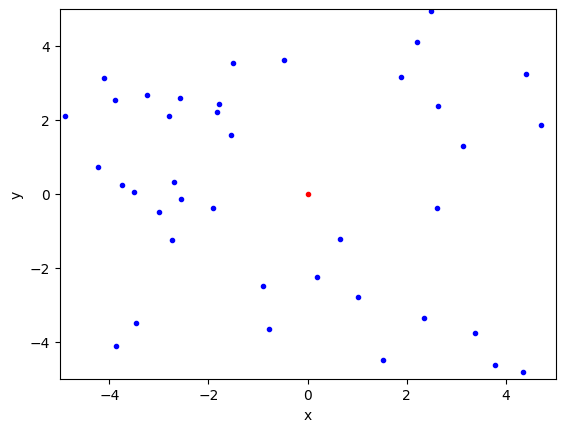

In [14]:
# Inspecteren van beginsituatie
plt.figure()

plt.xlabel('x')
plt.ylabel('y')

plt.xlim(-Box_length_0,Box_length_0)
plt.ylim(-Box_length_0,Box_length_0)


for particle, particle_object in enumerate(particles):
    plt.plot(particle_object.r[0],particle_object.r[1],color=particle_object.c,marker='.')
    #plt.arrow(particle_object.r[0],particle_object.r[1], 
     #          particle_object.v[0],particle_object.v[1], 
      #         head_width=0.05, head_length=0.1, color='red')
plt.show()


In [15]:
collisions_list = []
# Het bepalen of er een botsing plaats vindt
def collide_detection(self, other):
    dx = self.r[0] - other.r[0]
    dy = self.r[1] - other.r[1]
    rr = self.R + other.R
    return  dx**2+dy**2 < rr**2 
        
def particle_collision(p1: ParticleClass, p2: ParticleClass):
    """ past snelheden aan uitgaande van overlap """
    m1, m2 = p1.m, p2.m
    delta_r = p1.r - p2.r
    delta_v = p1.v - p2.v
    dot_product = np.dot(delta_r, delta_v)
    
    # Als deeltjes van elkaar weg bewegen dan geen botsing
    if dot_product >= 0: # '='-teken voorkomt ook problemen als delta_r == \vec{0}
        return
    
    distance_squared = np.dot(delta_r, delta_r) 
    # Botsing oplossen volgens elastische botsing in 2D
    p1.v -= 2 * m2 / (m1 + m2) * dot_product / distance_squared * delta_r
    p2.v += 2 * m1 / (m1 + m2) * dot_product / distance_squared * delta_r

def handle_collisions(particles):
    """ alle onderlinge botsingen afhandelen voor deeltjes in lijst """
    counter = 0
    num_particles = len(particles)
    for i in range(num_particles):
        for j in range(i+1, num_particles):
            if collide_detection(particles[i], particles[j]):
                particle_collision(particles[i], particles[j])
                counter += 1
    collisions_list.append(counter)


In onderstaande code geven we de code voor de simulatie en volgen we de positie van het zware deeltje. 

```{exercise} Brownian motion in beeld
:label: ex-brownian-3
- Draai de onderstaande simulatie een keer en bestudeer de output.
- Voeg zelf een tweede tracking toe van een licht deeltje en verbeter de plot.
- Wat zijn overeenkomsten en verschillen tussen de beweging van de twee deeltjes?
- Wat valt je op als je de simulatie een aantal keer runt?
```

```{solution} ex-brownian-3

Een grote overeenkomst tussen de beweging van de twee deeltjes is dat de twee routes vaak een zelfde vorm aannemen, vooral in richting.

Een groot verschil tussen de beweging van de twee deeltjes is dat het zwaardere deeltje veel minder ver beweegt. De afgelegde weg van het zwaardere deeltje is veel kleiner dan het lichtere deeltje. 
Daarbij maakt het zware deeltje veel minder vaak scherpe hoeken en draaien en blijft het zware deeltje zijn richting behouden ten opzichte van het lichte deeltje. 
```






In [16]:
# tracken van het zware deeltje
track_x = []
track_y = []

# tracken van het lichte deeltje
track_x_licht = []
track_y_licht = []

track_x_all = []
track_y_all = []

for i in range(N):
    track_x_all.append([])
    track_y_all.append([])
    
for i in range(400):
    
    for p in particles:
        p.update_position()    # Update positie        
        p.boxcollision()         # Wandbotsing werkt per deeltje
        
    handle_collisions(particles)
    
    track_x.append(particles[N-1].r[0])
    track_y.append(particles[N-1].r[1])
    track_x_licht.append(particles[0].r[0])
    track_y_licht.append(particles[0].r[1])
    for j in range(N):
        track_x_all[j].append(particles[j].r[0])
        track_y_all[j].append(particles[j].r[1])

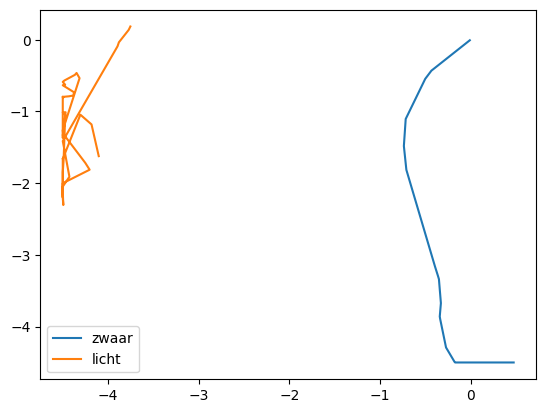

In [17]:
plt.figure()
plt.plot(track_x,track_y, label="zwaar")
plt.plot(track_x_licht,track_y_licht, label="licht")
plt.legend()
plt.show()

We zouden gevoel willen krijgen voor het aantal botsingen dat per tijdseenheid plaatsvinden. 
Elke keer dat er een botsing plaats vindt, zou de counter met 1 omhoog moeten gaan.
Idealiter wordt het aantal botsingen opgeslagen in een array zodat je het aantal botsingen als functie van de tijd kunt weergeven.

```{exercise}
Pas bovenstaand idee toe in de eerder gemaakte code.
Plot hieronder het aantal botsingen als functie van de tijd.
```


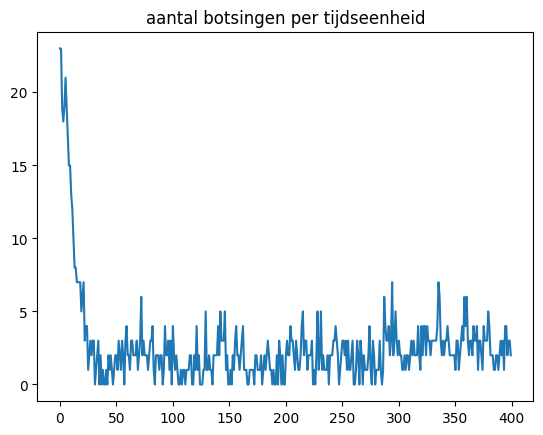

In [8]:
plt.figure()
plt.title("aantal botsingen per tijdseenheid")
plt.plot(collisions_list)
plt.show()

```{warning} 🌶 Let op!
:icon: false
De onderstaande opdrachten vallen buiten de stof maar telt mee als je excellent wilt behalen.
```

In zulke fysica modellen is de afgelegde weg van belang.
Deze afgelegde weg zegt iets over de snelheid van difussie. 

```{exercise} Afgelegde weg 🌶
:label: ex-brownian-4

Maak een histogram van de afgelegde weg voor alle deeltjes. 
Geef de afgelegde weg van het grote deeltje duidelijk aan.
```


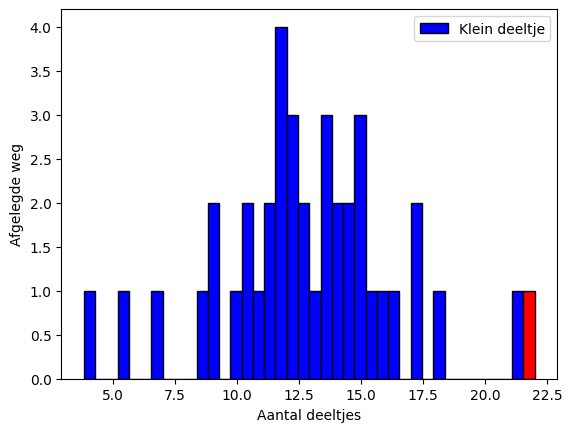

In [9]:
distance = []
for i in range(0,len(track_x_all)):
    afstand_counter = 0
    for j in range(1,len(track_x_all[i])):
        #pytagoras. sqrt(dx^2+dy^2) 
        afstand_counter += np.sqrt((track_x_all[i][j-1] - track_x_all[i][j])*(track_x_all[i][j-1] - track_x_all[i][j]) + (track_y_all[i][j-1] - track_y_all[i][j])*(track_y_all[i][j-1] - track_y_all[i][j]))
    distance.append(afstand_counter)

plt.figure()
n, bins, patches = plt.hist(distance, bins=N, color='blue', label='Klein deeltje', edgecolor='black')
patches[-1].set_facecolor('red')
plt.xlabel('Aantal deeltjes')
plt.ylabel("Afgelegde weg")
plt.legend()
plt.show() 

En nu we toch bezig zijn met twee verschillende deeltjes.... 

We kunnen twee "groepen" van deeltjes aanmaken, elk  met een andere massa. Als we dan de zwaartekracht aan zetten, dan zouden we verwachten dat de lichtere deeltjes boven komen "drijven".

```{exercise} Onderzoek dit vermoeden 🌶
```

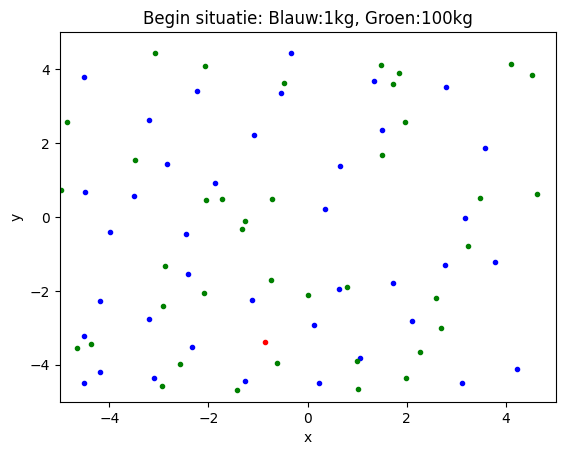

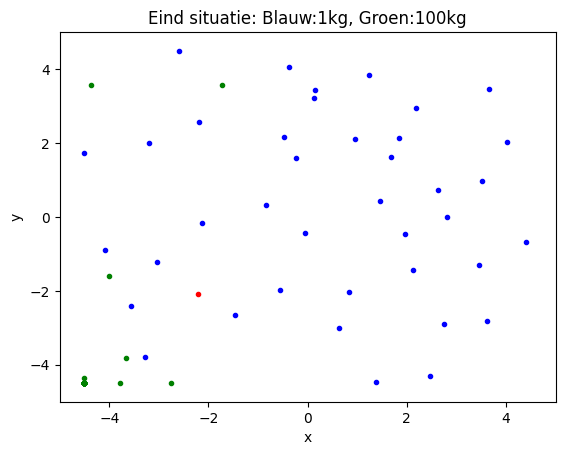

In [10]:
# Jouw code
meer_deeltjes = particles

# Aanmaken van deeltjes
for i in range(N-1):
    vx = np.random.uniform(-v_0,v_0)
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)        
    pos = Box_length_0*np.random.uniform(-1,1,2)
    meer_deeltjes.append(ParticleClass(m=100.0, v=[vx, vy], r = pos, R=.5,c='green'))


# Inspecteren van beginsituatie
plt.figure()

plt.xlabel('x')
plt.ylabel('y')
plt.title("Begin situatie: Blauw:1kg, Groen:100kg")
plt.xlim(-Box_length_0,Box_length_0)
plt.ylim(-Box_length_0,Box_length_0)


for particle, particle_object in enumerate(meer_deeltjes):
    plt.plot(particle_object.r[0],particle_object.r[1],color=particle_object.c,marker='.')
    #plt.arrow(particle_object.r[0],particle_object.r[1], 
     #          particle_object.v[0],particle_object.v[1], 
      #         head_width=0.05, head_length=0.1, color='red')
plt.show()


for i in range(5000):
    
    for p in meer_deeltjes:
        p.update_position()    # Update positie        
        p.boxcollision()         # Wandbotsing werkt per deeltje
        
    handle_collisions(meer_deeltjes)

# Inspecteren van eindsituatie
plt.figure()

plt.xlabel('x')
plt.ylabel('y')
plt.title("Eind situatie: Blauw:1kg, Groen:100kg")
plt.xlim(-Box_length_0,Box_length_0)
plt.ylim(-Box_length_0,Box_length_0)


for particle, particle_object in enumerate(meer_deeltjes):
    plt.plot(particle_object.r[0],particle_object.r[1],color=particle_object.c,marker='.')
    #plt.arrow(particle_object.r[0],particle_object.r[1], 
     #          particle_object.v[0],particle_object.v[1], 
      #         head_width=0.05, head_length=0.1, color='red')
plt.show()